<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week15/Day2/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP Exercises: Advanced A/B Testing

## Google Colab — Complete Solution

This notebook covers:

1. Required sample-size calculation
2. Relationship between effect size and sample size
3. Impact of statistical power
4. Sequential testing
5. Bayesian A/B testing
6. Adaptive experimentation

All exercises contain executable Python code, results, visualizations, and written answers.


## 1. Install and import the required libraries

In [1]:
%pip install -q statsmodels scipy pandas matplotlib

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import beta
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

pd.set_option("display.precision", 4)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# Exercise 1: Calculating Required Sample Size

We assume:

- Standardized effect size: `0.3`
- Statistical power: `0.8`
- Significance level: `0.05`
- Equal-sized control and treatment groups
- Two-sided hypothesis test

The null and alternative hypotheses are:

- **H₀:** The new subject line does not change the open rate.
- **H₁:** The new subject line changes the open rate.


In [2]:
power_analysis = NormalIndPower()

effect_size = 0.3
alpha = 0.05
power = 0.8

required_sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="two-sided"
)

required_sample_size_rounded = math.ceil(required_sample_size)

print("Calculated sample size:", required_sample_size)
print(
    "Required sample size per group:",
    required_sample_size_rounded
)
print(
    "Total experiment sample size:",
    required_sample_size_rounded * 2
)

Calculated sample size: 174.41912242947043
Required sample size per group: 175
Total experiment sample size: 350


### Answer

The test requires **175 participants per group**, or **350 participants in total**, when the standardized effect size is treated as `0.3`.

The result is rounded upward because a fraction of a participant cannot be included, and rounding downward would slightly reduce the intended statistical power.


### Important methodological note

The statement describes an increase from 20% to 23% and also calls this an effect size of `0.3`. These are not equivalent under Cohen's *h* for proportions.

The following cell calculates the actual standardized effect size associated with a change from 20% to 23%.


In [3]:
baseline_rate = 0.20
expected_rate = 0.23

actual_cohens_h = abs(
    proportion_effectsize(
        expected_rate,
        baseline_rate
    )
)

actual_required_sample = power_analysis.solve_power(
    effect_size=actual_cohens_h,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="two-sided"
)

print("Cohen's h for 20% versus 23%:", actual_cohens_h)
print(
    "Sample size per group for the literal 20% → 23% change:",
    math.ceil(actual_required_sample)
)

Cohen's h for 20% versus 23%: 0.0730639993933625
Sample size per group for the literal 20% → 23% change: 2941


The literal increase from 20% to 23% corresponds to a much smaller standardized effect than `0.3`, so detecting that exact change requires a substantially larger sample.

For the official exercise answer, we continue using the stated effect size of `0.3`.


# Exercise 2: Effect Size and Sample Size

We calculate the required sample size for effect sizes:

- `0.2`
- `0.4`
- `0.5`

Power remains `0.8`, and alpha remains `0.05`.


In [4]:
effect_sizes = [0.2, 0.4, 0.5]

effect_size_results = []

for current_effect_size in effect_sizes:
    sample_size = power_analysis.solve_power(
        effect_size=current_effect_size,
        alpha=0.05,
        power=0.8,
        ratio=1,
        alternative="two-sided"
    )

    effect_size_results.append({
        "effect_size": current_effect_size,
        "sample_size_per_group": math.ceil(sample_size),
        "total_sample_size": math.ceil(sample_size) * 2
    })

effect_size_df = pd.DataFrame(effect_size_results)

display(effect_size_df)

,effect_size,sample_size_per_group,total_sample_size
0,0.2,393,786
1,0.4,99,198
2,0.5,63,126


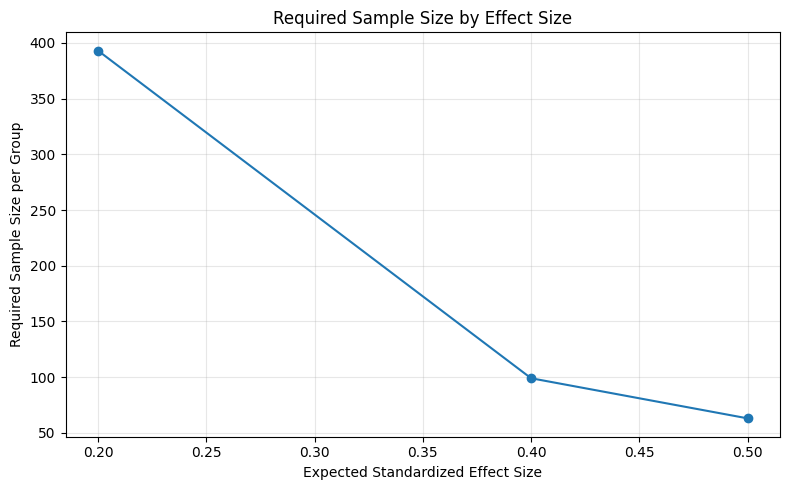

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    effect_size_df["effect_size"],
    effect_size_df["sample_size_per_group"],
    marker="o"
)

plt.title("Required Sample Size by Effect Size")
plt.xlabel("Expected Standardized Effect Size")
plt.ylabel("Required Sample Size per Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Answer

The required sample sizes are approximately:

- Effect size `0.2`: **393 participants per group**
- Effect size `0.4`: **99 participants per group**
- Effect size `0.5`: **63 participants per group**

As the expected effect size increases, the required sample size decreases.

A larger effect is easier to distinguish from random variation. A smaller effect is harder to detect because the distributions of the control and treatment groups overlap more, requiring more observations to obtain sufficient statistical evidence.


# Exercise 3: Impact of Statistical Power

We keep:

- Effect size: `0.2`
- Alpha: `0.05`

We compare power levels:

- `0.7`
- `0.8`
- `0.9`


In [6]:
power_levels = [0.7, 0.8, 0.9]

power_results = []

for current_power in power_levels:
    sample_size = power_analysis.solve_power(
        effect_size=0.2,
        alpha=0.05,
        power=current_power,
        ratio=1,
        alternative="two-sided"
    )

    power_results.append({
        "power": current_power,
        "sample_size_per_group": math.ceil(sample_size),
        "total_sample_size": math.ceil(sample_size) * 2
    })

power_df = pd.DataFrame(power_results)

display(power_df)

,power,sample_size_per_group,total_sample_size
0,0.7,309,618
1,0.8,393,786
2,0.9,526,1052


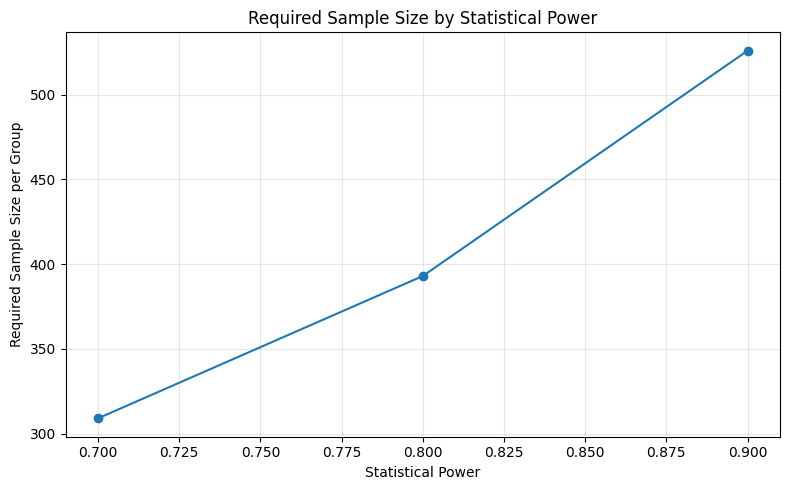

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    power_df["power"],
    power_df["sample_size_per_group"],
    marker="o"
)

plt.title("Required Sample Size by Statistical Power")
plt.xlabel("Statistical Power")
plt.ylabel("Required Sample Size per Group")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Answer

The required sample sizes are approximately:

- Power `0.7`: **309 participants per group**
- Power `0.8`: **393 participants per group**
- Power `0.9`: **526 participants per group**

Higher statistical power requires a larger sample because the test must have a greater probability of detecting a real effect.

This is important because low-powered experiments can miss meaningful improvements, producing a **Type II error**. However, very high power can require substantially more time, traffic, and money. Experiment designers must balance sensitivity with practical constraints.


# Exercise 4: Sequential Testing

## Why ordinary repeated testing is dangerous

Checking an ordinary p-value every week and stopping as soon as it falls below `0.05` inflates the probability of a false positive.

A valid sequential design should define in advance:

- Maximum number of analyses
- Timing of each analysis
- Success boundary
- Futility boundary
- Minimum sample size
- Primary metric
- Guardrail metrics

For this example, we plan three weekly analyses and use a simple **Bonferroni correction**:

\[
\alpha_{look} = \frac{0.05}{3}
\]

This is conservative but easy to explain and implement.


In [8]:
overall_alpha = 0.05
planned_looks = 3

alpha_per_look = overall_alpha / planned_looks

print("Overall alpha:", overall_alpha)
print("Planned analyses:", planned_looks)
print("Significance threshold at each look:", alpha_per_look)

Overall alpha: 0.05
Planned analyses: 3
Significance threshold at each look: 0.016666666666666666


## Proposed stopping criteria

Stop early for success only when all of the following conditions are met:

1. The adjusted p-value boundary is crossed.
2. Version B performs better than Version A.
3. The minimum sample size for the current checkpoint has been reached.
4. The improvement is practically meaningful.
5. No important guardrail metric has deteriorated.

Possible futility rule:

- Stop if the conditional probability of eventually detecting the target effect becomes very low.


In [9]:
def sequential_decision(
    p_value,
    observed_lift,
    minimum_lift,
    sample_size_reached,
    guardrails_ok,
    alpha_boundary
):
    if not sample_size_reached:
        return "Continue: minimum checkpoint sample size not reached."

    if not guardrails_ok:
        return "Stop or investigate: a guardrail metric deteriorated."

    if (
        p_value < alpha_boundary
        and observed_lift >= minimum_lift
    ):
        return "Stop early and declare Version B the winner."

    return "Continue collecting data."


week_three_p_value = 0.02

decision = sequential_decision(
    p_value=week_three_p_value,
    observed_lift=0.05,
    minimum_lift=0.03,
    sample_size_reached=True,
    guardrails_ok=True,
    alpha_boundary=alpha_per_look
)

print("Week-three p-value:", week_three_p_value)
print("Adjusted threshold:", alpha_per_look)
print("Decision:", decision)

Week-three p-value: 0.02
Adjusted threshold: 0.016666666666666666
Decision: Continue collecting data.


### Answer

At the end of week three, the ordinary p-value is `0.02`.

Under the predefined Bonferroni boundary, the significance threshold is approximately `0.0167`. Since `0.02` is greater than `0.0167`, I would **not declare Version B the winner**.

I would complete the planned experiment or apply the previously selected sequential-testing procedure. I would not change the stopping rule after seeing the result.

Had the experiment used a formally specified alpha-spending design with a week-three boundary above `0.02`, the decision could differ. The critical point is that the rule must be chosen before examining the data.


# Exercise 5: Bayesian A/B Testing

## Prior belief

A 50% prior probability that the feature is better represents a neutral belief: before seeing the experiment, neither version is favored.

For binary engagement outcomes, we can model each conversion rate with a Beta distribution.

A weak neutral prior can be represented as:

- Control: `Beta(1, 1)`
- Treatment: `Beta(1, 1)`

After observing successes and failures, the posterior becomes:

\[
Beta(\alpha + successes,\; \beta + failures)
\]


In [10]:
def bayesian_ab_probability(
    control_successes,
    control_trials,
    treatment_successes,
    treatment_trials,
    prior_alpha=1,
    prior_beta=1,
    simulations=200_000,
    random_state=42
):
    local_rng = np.random.default_rng(random_state)

    control_posterior_alpha = (
        prior_alpha + control_successes
    )
    control_posterior_beta = (
        prior_beta
        + control_trials
        - control_successes
    )

    treatment_posterior_alpha = (
        prior_alpha + treatment_successes
    )
    treatment_posterior_beta = (
        prior_beta
        + treatment_trials
        - treatment_successes
    )

    control_samples = local_rng.beta(
        control_posterior_alpha,
        control_posterior_beta,
        simulations
    )

    treatment_samples = local_rng.beta(
        treatment_posterior_alpha,
        treatment_posterior_beta,
        simulations
    )

    probability_treatment_better = np.mean(
        treatment_samples > control_samples
    )

    expected_lift = np.mean(
        treatment_samples - control_samples
    )

    return {
        "probability_treatment_better": probability_treatment_better,
        "expected_absolute_lift": expected_lift,
        "control_samples": control_samples,
        "treatment_samples": treatment_samples
    }


bayesian_example = bayesian_ab_probability(
    control_successes=200,
    control_trials=1000,
    treatment_successes=208,
    treatment_trials=1000
)

print(
    "Posterior probability treatment is better:",
    round(
        bayesian_example[
            "probability_treatment_better"
        ],
        4
    )
)

print(
    "Expected absolute lift:",
    round(
        bayesian_example[
            "expected_absolute_lift"
        ],
        4
    )
)

Posterior probability treatment is better: 0.6701
Expected absolute lift: 0.0079


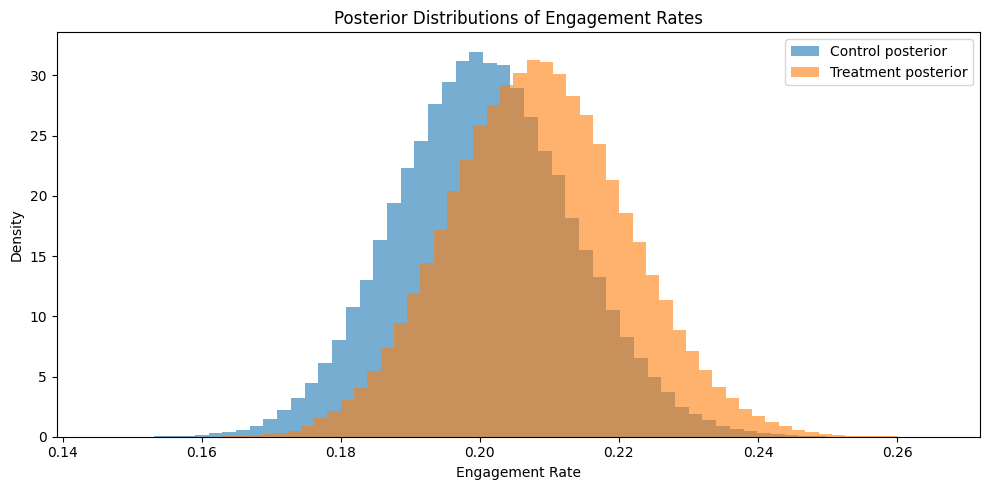

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    bayesian_example["control_samples"],
    bins=60,
    density=True,
    alpha=0.6,
    label="Control posterior"
)

plt.hist(
    bayesian_example["treatment_samples"],
    bins=60,
    density=True,
    alpha=0.6,
    label="Treatment posterior"
)

plt.title("Posterior Distributions of Engagement Rates")
plt.xlabel("Engagement Rate")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Answers

#### How would I set up the prior?

I would use a neutral prior that gives the new feature a 50% chance of being better. For binary engagement, a weak `Beta(1, 1)` prior for each version is a reasonable starting point when there is little reliable historical evidence.

A stronger prior could be used when trustworthy previous experiments exist, but its assumptions should be documented.

#### How does a 65% posterior probability influence the decision?

A 65% posterior probability means that, given the prior and observed data, there is a 65% probability that the new feature performs better.

This is evidence in favor of the feature, but it is usually not strong enough for a high-confidence launch. I would also examine:

- Expected improvement
- Probability of exceeding a minimum practical lift
- Expected business value
- Cost of a wrong decision
- Guardrail metrics

I would normally continue collecting data unless the decision is low-risk and the potential benefit justifies acting with moderate uncertainty.

#### What if the posterior probability were only 55%?

A 55% probability is close to uncertainty. I would not claim that the feature is better. I would continue the experiment if additional data are economical, or stop for futility if the expected value of further testing is low.


# Exercise 6: Adaptive Experimentation

The experiment starts with equal allocation:

- Layout A: 33%
- Layout B: 33%
- Layout C: 33%

After the first week, Layout C appears to have higher engagement.


## Recommended traffic adjustment

I would not immediately send all traffic to Layout C. Early results can be noisy.

A reasonable first adjustment could be:

- Layout A: 25%
- Layout B: 25%
- Layout C: 50%

This exploits the currently stronger option while retaining enough traffic for the other layouts to continue learning.

A minimum exploration allocation should be maintained for every active layout.


In [12]:
initial_allocation = pd.Series({
    "Layout A": 1 / 3,
    "Layout B": 1 / 3,
    "Layout C": 1 / 3
})

week_two_allocation = pd.Series({
    "Layout A": 0.25,
    "Layout B": 0.25,
    "Layout C": 0.50
})

allocation_comparison = pd.DataFrame({
    "initial_allocation": initial_allocation,
    "week_two_allocation": week_two_allocation
})

display(
    (allocation_comparison * 100)
    .round(2)
    .rename_axis("layout")
)

,initial_allocation,week_two_allocation
layout,,
Layout A,33.33,25.0
Layout B,33.33,25.0
Layout C,33.33,50.0


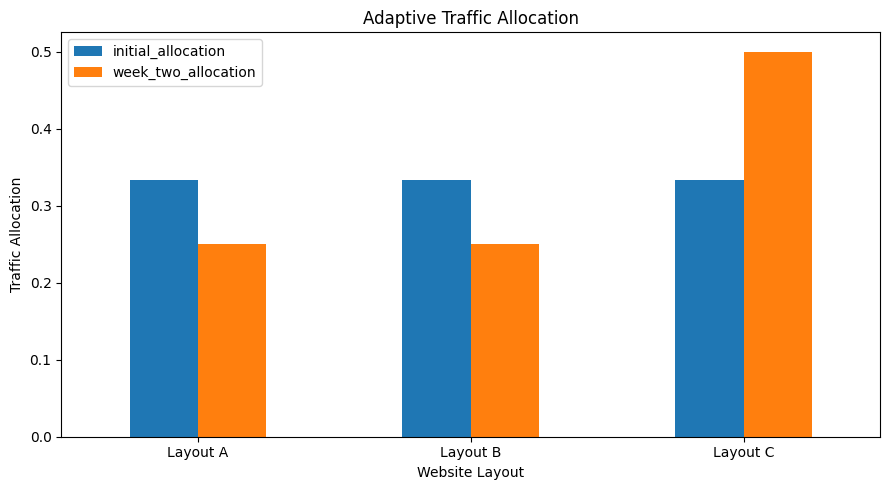

In [13]:
allocation_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Adaptive Traffic Allocation")
plt.xlabel("Website Layout")
plt.ylabel("Traffic Allocation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Continuing adaptation

In later weeks, I would:

1. Update the performance estimates at predefined intervals.
2. Increase traffic gradually toward layouts with stronger posterior evidence or higher expected reward.
3. Maintain a minimum exploration share, such as 10%–15%, for every active layout.
4. Remove a clearly inferior layout only after a predefined futility criterion is reached.
5. Stop when one layout meets the predefined probability, practical-effect, sample-size, and guardrail requirements.

A multi-armed bandit method such as **Thompson sampling** could automate this balance between exploration and exploitation.


In [14]:
def thompson_sampling_allocation(
    successes,
    trials,
    prior_alpha=1,
    prior_beta=1,
    simulations=100_000,
    minimum_share=0.10,
    random_state=42
):
    local_rng = np.random.default_rng(random_state)
    layouts = list(successes.keys())

    posterior_draws = []

    for layout in layouts:
        alpha_posterior = (
            prior_alpha + successes[layout]
        )
        beta_posterior = (
            prior_beta
            + trials[layout]
            - successes[layout]
        )

        draws = local_rng.beta(
            alpha_posterior,
            beta_posterior,
            simulations
        )

        posterior_draws.append(draws)

    posterior_matrix = np.column_stack(
        posterior_draws
    )

    winner_indices = np.argmax(
        posterior_matrix,
        axis=1
    )

    winner_probabilities = np.bincount(
        winner_indices,
        minlength=len(layouts)
    ) / simulations

    remaining_share = (
        1 - minimum_share * len(layouts)
    )

    adaptive_shares = (
        minimum_share
        + remaining_share * winner_probabilities
    )

    return pd.DataFrame({
        "layout": layouts,
        "probability_best": winner_probabilities,
        "recommended_traffic_share": adaptive_shares
    })


example_adaptive_result = thompson_sampling_allocation(
    successes={
        "Layout A": 180,
        "Layout B": 190,
        "Layout C": 225
    },
    trials={
        "Layout A": 1000,
        "Layout B": 1000,
        "Layout C": 1000
    }
)

display(example_adaptive_result.round(4))

,layout,probability_best,recommended_traffic_share
0,Layout A,0.0054,0.1038
1,Layout B,0.0269,0.1188
2,Layout C,0.9677,0.7774


## Challenges and solutions

### 1. Early random noise

A layout can appear superior by chance during the first week.

**Solution:** Require minimum samples, use regularization through priors, and update only at predefined intervals.

### 2. Reduced comparability

Traffic allocation changes over time, and user populations may also change.

**Solution:** Log assignment probabilities, time, device, geography, and other relevant context. Use estimators designed for adaptive allocation.

### 3. Insufficient exploration

Sending too little traffic to weaker layouts can prevent learning whether they are actually competitive.

**Solution:** Enforce a minimum traffic allocation for every active treatment.

### 4. Delayed outcomes

Conversions or engagement may occur after assignment.

**Solution:** Use an appropriate attribution window and avoid updating allocations before outcomes mature.

### 5. Operational complexity

Adaptive experiments are harder to explain, monitor, and analyze than fixed randomized tests.

**Solution:** Predefine the algorithm, stopping rules, metrics, safeguards, and reporting process.

### 6. Business and ethical risks

Automatically directing users toward a treatment can be harmful if guardrails are ignored.

**Solution:** Monitor safety, user experience, latency, complaints, and other guardrail metrics continuously.


# Final Summary

- Smaller expected effects require larger samples.
- Higher statistical power also requires larger samples.
- Sequential testing must adjust for repeated analyses.
- Bayesian testing updates prior beliefs with observed evidence.
- A posterior probability such as 65% is suggestive but not necessarily decisive.
- Adaptive experimentation can improve total reward during the test, but it requires safeguards to preserve learning and valid inference.
- Statistical significance should always be considered together with practical significance, uncertainty, cost, and business risk.
